Vamos entender os Dados e o Problema de Negócio (Campanhas de Marketing)

1. **Qualidade dos Dados**

* Qualidade e Estrutura dos Dados.
* Conferir valores únicos por coluna.
* Verificar distribuição de valores nulos (nesse caso parece não ter).
* Checar tipos de dados corretos (ex.: Date → datetime, Conversion_Rate → float).

2. **Visão Geral de Campanhas**

* Quantidade de campanhas por empresa e por tipo de campanha.
* Duração média das campanhas por tipo de campanha.
* Comparação entre canais usados em termos de volume de campanhas.

3. **Performance de Campanhas**

* Distribuição da taxa de conversão por tipo de campanha.
* Campanhas com melhor e pior ROI.
* Relação entre custo de aquisição por tipo de campanha.
* Média de custo de aquisição por tipo de campanha
* Comparação do ROI médio por tipo de campanha e canal.

4. **Análise de Audiência**

* Conversão média por audiência.
* Comparar ROI por segmento de cliente.
* Verificar se diferentes linguagens impactam a performance.

5. **Marketing Digital – Métricas de Engajamento**

* Relação entre Impressões → Clicks → Taxa de engajamento.
* CTR (Click-through rate) = Clicks / Impressões.
* Correlação entre EngaTaxa de engajamento e Taxa de conversão.
* Distribuição de engajamento por canal.

6. **Análise Temporal**

* Evolução da taxa de conversão ao longo do tempo (Date).
* Identificação de sazonalidade (quais meses/ciclos têm melhor ROI).
* Duração da campanha vs. taxa de conversão (curtas performam melhor?).

7. **Geografia**

* Distribuição de campanhas por Location.
* Conversão média por região.
* ROI por localização → identificar regiões mais rentáveis.

8. **Relações Multivariadas**

* ROI em função de Custo de Aquisição × Taxa de Conversão.
* Campanhas com alta conversão mas ROI baixo (custo elevado).
* Segmentos com baixo custo de aquisição mas alta taxa de conversão.

9. **Perspectiva Financeira**

* Cálculo de CAC médio = soma(Custo de Aquisição) / número de conversões).
* ROI agregado por empresa.
* Identificação de top 10 campanhas mais rentáveis.
* Identificação de campanhas deficitárias (ROI < 0).

10. **Para Preparação de Modelagem**

* Criar features derivadas:
  * CTR = Clicks / Impressions
  * Custo_por_Click = Acquisition_Cost / Clicks
  * Conversao_por_Impressao = Conversion_Rate * Clicks / Impressions
  * ROI_binário = ROI > 0 (classificação).

Verificar correlações entre variáveis numéricas (Conversion_Rate, Acquisition_Cost, ROI, Engagement_Score, etc.).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importando os dados

In [ ]:
df = pd.read_csv('marketing_campaign_dataset.csv')

print(df.shape)
df.head()

(200000, 16)


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [ ]:
def tabela_metadados(df):
    tabela = pd.DataFrame({
        "variavel": df.columns,
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum().values,
        "pct_nulos": (df.isna().mean().values * 100).round(2)
    })

    # ajustar tipo mais legível
    tabela["tipo"] = tabela["tipo"].replace({
        "object": "categorica",
        "category": "categorica",
        "int64": "numerica",
        "float64": "numerica",
        "datetime64[ns]": "data"
    })

    # adicionar cardinalidade (somente para categóricas)
    tabela["cardinalidade"] = [
        df[col].nunique() if tipo == "categorica" else None
        for col, tipo in zip(tabela["variavel"], tabela["tipo"])
    ]

    return tabela

metadados = tabela_metadados(df)
metadados

,variavel,tipo,n_nulos,pct_nulos,cardinalidade
Campaign_ID,Campaign_ID,numerica,0,0.0,NaN
Company,Company,categorica,0,0.0,5.0
Campaign_Type,Campaign_Type,categorica,0,0.0,5.0
Target_Audience,Target_Audience,categorica,0,0.0,5.0
Duration,Duration,categorica,0,0.0,4.0
Channel_Used,Channel_Used,categorica,0,0.0,6.0
Conversion_Rate,Conversion_Rate,numerica,0,0.0,NaN
Acquisition_Cost,Acquisition_Cost,categorica,0,0.0,15001.0
ROI,ROI,numerica,0,0.0,NaN
Location,Location,categorica,0,0.0,5.0


In [ ]:
df.dtypes

,0
Campaign_ID,int64
Company,object
Campaign_Type,object
Target_Audience,object
Duration,object
Channel_Used,object
Conversion_Rate,float64
Acquisition_Cost,object
ROI,float64
Location,object


## Conhecendo os valores

In [ ]:
# Verificando valores de Company
df['Company'].value_counts()

,count
Company,
TechCorp,40237
Alpha Innovations,40051
DataTech Solutions,40012
NexGen Systems,39991
Innovate Industries,39709


In [ ]:
# Verificando valores de Campaign_Type
df['Campaign_Type'].value_counts()

,count
Campaign_Type,
Influencer,40169
Search,40157
Display,39987
Email,39870
Social Media,39817


In [ ]:
# Verificando valores de Target_Audience
df['Target_Audience'].value_counts()

,count
Target_Audience,
Men 18-24,40258
Men 25-34,40023
All Ages,40019
Women 25-34,40013
Women 35-44,39687


In [ ]:
# Verificando valores de Duration
df['Duration'].value_counts()

,count
Duration,
30 days,50255
45 days,50100
60 days,49866
15 days,49779


In [ ]:
# Remover a palavra "days" e converter para inteiro
df['Duration'] = df['Duration'].str.replace(' days', '', regex=False).astype(int)

# Verificar resultado
print(df['Duration'].unique())
print(df['Duration'].dtype)

[30 60 15 45]
int64


In [ ]:
# Verificando valores de Channel_Used
df['Channel_Used'].value_counts()

,count
Channel_Used,
Email,33599
Google Ads,33438
YouTube,33392
Instagram,33392
Website,33360
Facebook,32819


In [ ]:
# Verificando valores de Conversion_Rate
df['Conversion_Rate'].value_counts()

,count
Conversion_Rate,
0.13,14468
0.10,14437
0.06,14402
0.11,14399
0.02,14386
0.04,14339
0.09,14318
0.12,14263
0.08,14251


In [ ]:
# Verificando valores de Acquisition_Cost
df['Acquisition_Cost'].value_counts()

,count
Acquisition_Cost,
"$16,578.00",32
"$6,570.00",31
"$9,128.00",30
"$8,503.00",29
"$15,430.00",29
...,...
"$7,917.00",3
"$7,878.00",3
"$7,443.00",3


In [ ]:
# Remover símbolo de dólar e vírgula, depois converter para float
df['Acquisition_Cost'] = (
    df['Acquisition_Cost']
    .str.replace('$', '', regex=False)   # remove o $
    .str.replace(',', '', regex=False)   # remove as vírgulas
    .astype(float)                       # converte para float
)

# Conferir o resultado
print(df['Acquisition_Cost'].head())
print(df['Acquisition_Cost'].dtype)


0    16174.0
1    11566.0
2    10200.0
3    12724.0
4    16452.0
Name: Acquisition_Cost, dtype: float64
float64


In [ ]:
# Verificando valores de ROI
df['ROI'].value_counts()

,count
ROI,
7.43,407
4.25,383
6.05,378
5.89,375
7.69,374
...,...
6.38,282
7.09,280
6.99,274


In [ ]:
#Transformando em float
df['ROI'].astype(float)


,ROI
0,6.29
1,5.61
2,7.18
3,5.55
4,6.50
...,...
199995,2.84
199996,4.14
199997,3.25
199998,3.86


In [ ]:
# Verificando valores de Location
df['Location'].value_counts()

,count
Location,
Miami,40269
New York,40024
Chicago,40010
Los Angeles,39947
Houston,39750


In [ ]:
# Verificando valores de Language
df['Language'].value_counts()

,count
Language,
Mandarin,40255
Spanish,40102
German,39983
English,39896
French,39764


In [ ]:
# Verificando valores de Clicks
df['Clicks'].value_counts()

,count
Clicks,
477,273
262,266
726,266
140,266
232,262
...,...
896,187
302,186
427,185


In [ ]:
# Verificando valores de Impressions
df['Impressions'].value_counts()

,count
Impressions,
1602,41
3564,41
9471,41
3872,40
5694,40
...,...
2780,8
1753,8
8303,8


In [ ]:
# Verificando valores de Engagement_Score
df['Engagement_Score'].value_counts()

,count
Engagement_Score,
4,20141
2,20113
9,20106
1,20027
5,20023
3,19947
8,19944
7,19933
10,19884


In [ ]:
# Verificando valores de Customer_Segment
df['Customer_Segment'].value_counts()

,count
Customer_Segment,
Foodies,40208
Tech Enthusiasts,40151
Outdoor Adventurers,40011
Health & Wellness,39888
Fashionistas,39742


In [ ]:
# Verificando valores de Date

# Converter a coluna Date para datetime
df['Date'] = pd.to_datetime(df['Date'])

# Conferir o tipo da coluna
print(df['Date'].dtype)
print(df['Date'].head())

datetime64[ns]
0   2021-01-01
1   2021-01-02
2   2021-01-03
3   2021-01-04
4   2021-01-05
Name: Date, dtype: datetime64[ns]


In [ ]:
novo_metadados = tabela_metadados(df)
novo_metadados

,variavel,tipo,n_nulos,pct_nulos,cardinalidade
Campaign_ID,Campaign_ID,numerica,0,0.0,NaN
Company,Company,categorica,0,0.0,5.0
Campaign_Type,Campaign_Type,categorica,0,0.0,5.0
Target_Audience,Target_Audience,categorica,0,0.0,5.0
Duration,Duration,numerica,0,0.0,NaN
Channel_Used,Channel_Used,categorica,0,0.0,6.0
Conversion_Rate,Conversion_Rate,numerica,0,0.0,NaN
Acquisition_Cost,Acquisition_Cost,numerica,0,0.0,NaN
ROI,ROI,numerica,0,0.0,NaN
Location,Location,categorica,0,0.0,5.0


### Essa análise detalhada de cada item mostra uma base de qualidade bem equilibrada e sem outliner.

## Verificando valores faltantes e nulos

In [ ]:
df.isnull().sum()

,0
Campaign_ID,0
Company,0
Campaign_Type,0
Target_Audience,0
Duration,0
Channel_Used,0
Conversion_Rate,0
Acquisition_Cost,0
ROI,0
Location,0


A base não apresenta valores nulo.  

## Analisando as relações entre os dados

### Quantidade de campanhas por empresa e por tipo de campanha.

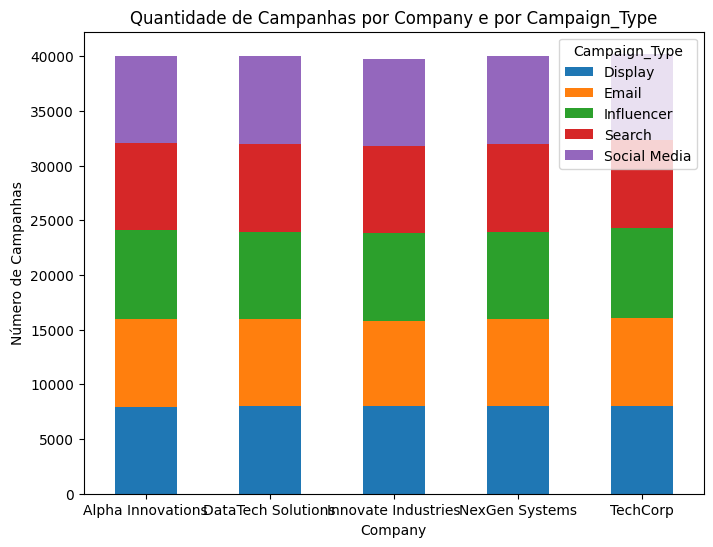

In [ ]:
# Agrupar por Company e Campaign_Type e contar campanhas
campaign_counts = df.groupby(["Company", "Campaign_Type"]).size().unstack(fill_value=0)

# Gráfico de barras empilhadas
campaign_counts.plot(kind="bar", stacked=True, figsize=(8,6))

# Personalização
plt.title("Quantidade de Campanhas por Company e por Campaign_Type")
plt.xlabel("Company")
plt.ylabel("Número de Campanhas")
plt.legend(title="Campaign_Type")
plt.xticks(rotation=0)

plt.show()

### Duração média das campanhas por tipo de campanha.

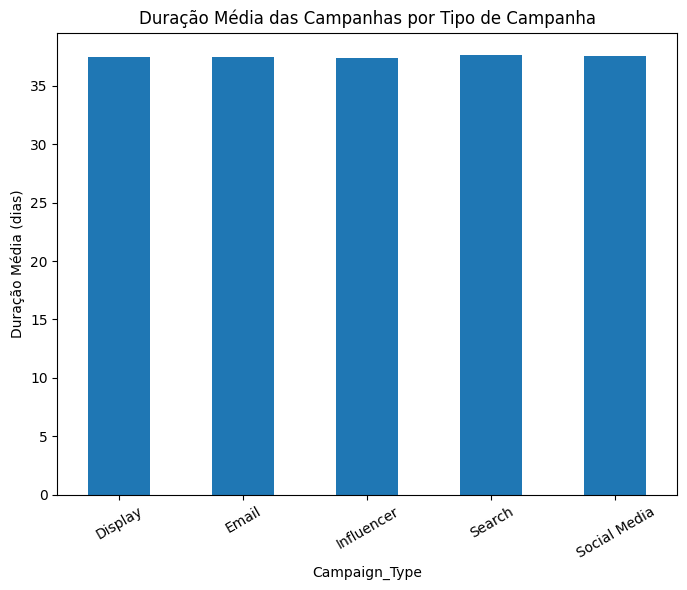

In [ ]:
# Calcular duração média por Campaign_Type
avg_duration = df.groupby("Campaign_Type")["Duration"].mean()

# Plotar gráfico
avg_duration.plot(kind="bar", figsize=(8,6))

# Personalização
plt.title("Duração Média das Campanhas por Tipo de Campanha")
plt.xlabel("Campaign_Type")
plt.ylabel("Duração Média (dias)")
plt.xticks(rotation=30)
plt.show()

### Comparação entre canais usados em termos de volume de campanhas.

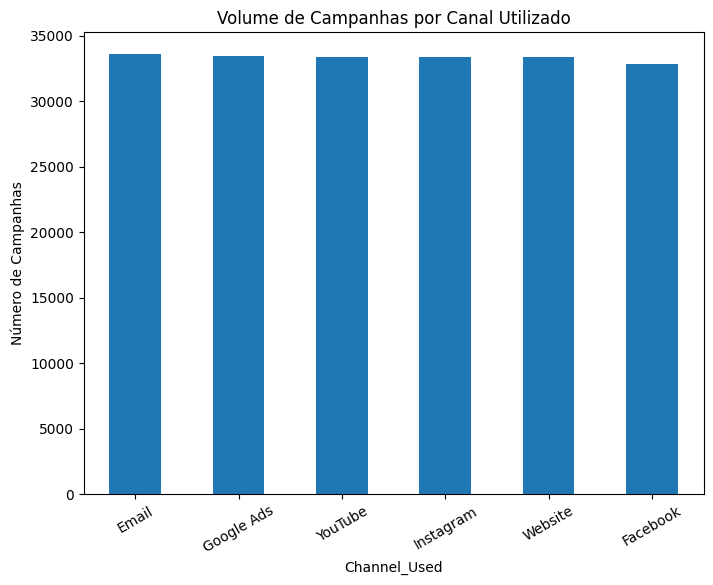

In [ ]:
# Contagem de campanhas por canal
channel_counts = df["Channel_Used"].value_counts()

# Plotar gráfico de barras
channel_counts.plot(kind="bar", figsize=(8,6))

# Personalização
plt.title("Volume de Campanhas por Canal Utilizado")
plt.xlabel("Channel_Used")
plt.ylabel("Número de Campanhas")
plt.xticks(rotation=30)
plt.show()

### Distribuição da taxa de conversão por tipo de campanha.

<Figure size 800x600 with 0 Axes>

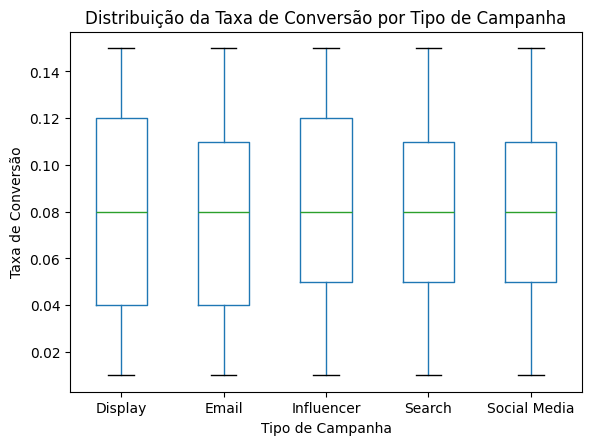

In [ ]:
# --- Boxplot da taxa de conversão por tipo de campanha ---
plt.figure(figsize=(8,6))
df.boxplot(column="Conversion_Rate", by="Campaign_Type", grid=False)
plt.title("Distribuição da Taxa de Conversão por Tipo de Campanha")
plt.suptitle("")  # remove o título automático do pandas
plt.xlabel("Tipo de Campanha")
plt.ylabel("Taxa de Conversão")
plt.show()

### Campanhas com melhor e pior ROI.

In [ ]:
# Top 5 campanhas com melhor ROI
melhores = df.sort_values(by="ROI", ascending=False).head(5)

print("📈 Melhores Campanhas por ROI:")
print(melhores)

📈 Melhores Campanhas por ROI:
        Campaign_ID              Company Campaign_Type Target_Audience  \
65640         65641    Alpha Innovations        Search     Women 25-34   
143790       143791    Alpha Innovations    Influencer       Men 18-24   
143503       143504  Innovate Industries    Influencer     Women 35-44   
121639       121640             TechCorp    Influencer       Men 18-24   
120917       120918             TechCorp  Social Media       Men 18-24   

        Duration Channel_Used  Conversion_Rate  Acquisition_Cost  ROI  \
65640         15      Website             0.09           18624.0  8.0   
143790        60      Website             0.06           17371.0  8.0   
143503        30      YouTube             0.04            5889.0  8.0   
121639        15   Google Ads             0.14            7081.0  8.0   
120917        45      Website             0.11            6677.0  8.0   

           Location Language  Clicks  Impressions  Engagement_Score  \
65640         M

In [ ]:
# Top 5 campanhas com pior ROI
piores = df.sort_values(by="ROI", ascending=True).head(5)

print("\n📉 Piores Campanhas por ROI:")
print(piores)


📉 Piores Campanhas por ROI:
        Campaign_ID         Company Campaign_Type Target_Audience  Duration  \
158656       158657        TechCorp         Email       Men 18-24        15   
19662         19663        TechCorp  Social Media        All Ages        30   
104137       104138  NexGen Systems    Influencer       Men 25-34        30   
57347         57348        TechCorp        Search     Women 25-34        30   
41738         41739        TechCorp        Search     Women 25-34        60   

       Channel_Used  Conversion_Rate  Acquisition_Cost  ROI  Location  \
158656        Email             0.07            9148.0  2.0  New York   
19662     Instagram             0.11           18949.0  2.0     Miami   
104137    Instagram             0.14           17934.0  2.0   Houston   
57347         Email             0.12            7562.0  2.0     Miami   
41738    Google Ads             0.13           17035.0  2.0     Miami   

        Language  Clicks  Impressions  Engagement_Score  

###  Relação entre custo de aquisição por tipo de campanha.

/tmp/ipython-input-3844405173.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Campaign_Type", y="Acquisition_Cost", palette="Set2")


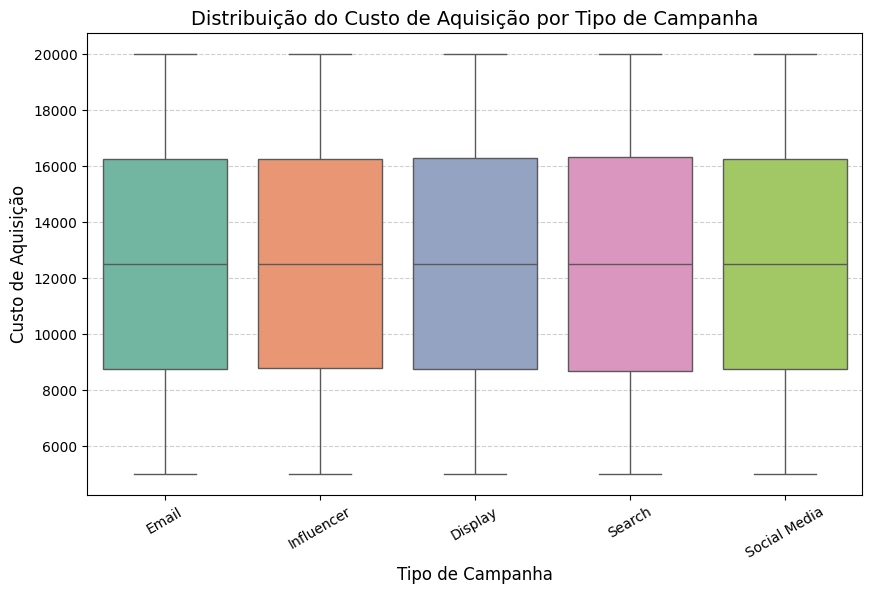

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Campaign_Type", y="Acquisition_Cost", palette="Set2")

plt.title("Distribuição do Custo de Aquisição por Tipo de Campanha", fontsize=14)
plt.xlabel("Tipo de Campanha", fontsize=12)
plt.ylabel("Custo de Aquisição", fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

### Média de custo de aquisição por tipo de campanha

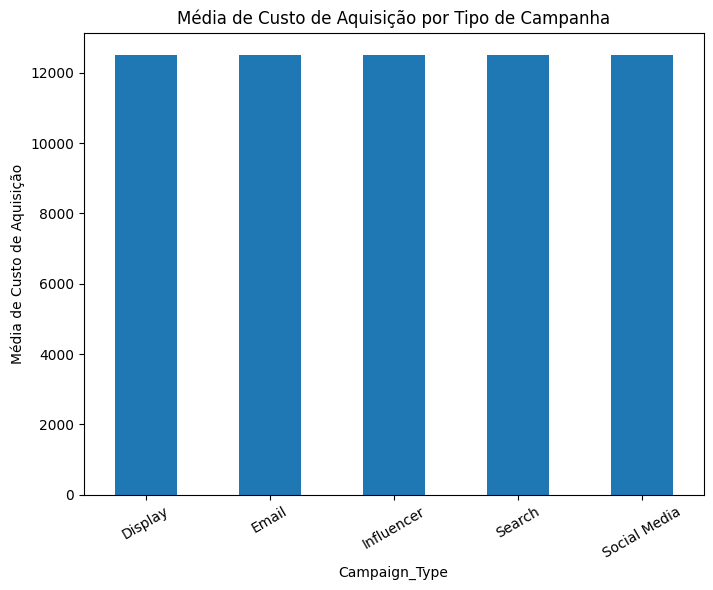

In [ ]:
# Calcular a média de custo de aquisição por tipo de campanha
avg_acquisition_cost = df.groupby("Campaign_Type")["Acquisition_Cost"].mean()

# Plotar gráfico de barras
avg_acquisition_cost.plot(kind="bar", figsize=(8,6))

# Personalização
plt.title("Média de Custo de Aquisição por Tipo de Campanha")
plt.xlabel("Campaign_Type")
plt.ylabel("Média de Custo de Aquisição")
plt.xticks(rotation=30)
plt.show()

### Comparação do ROI médio por tipo de campanha e canal.

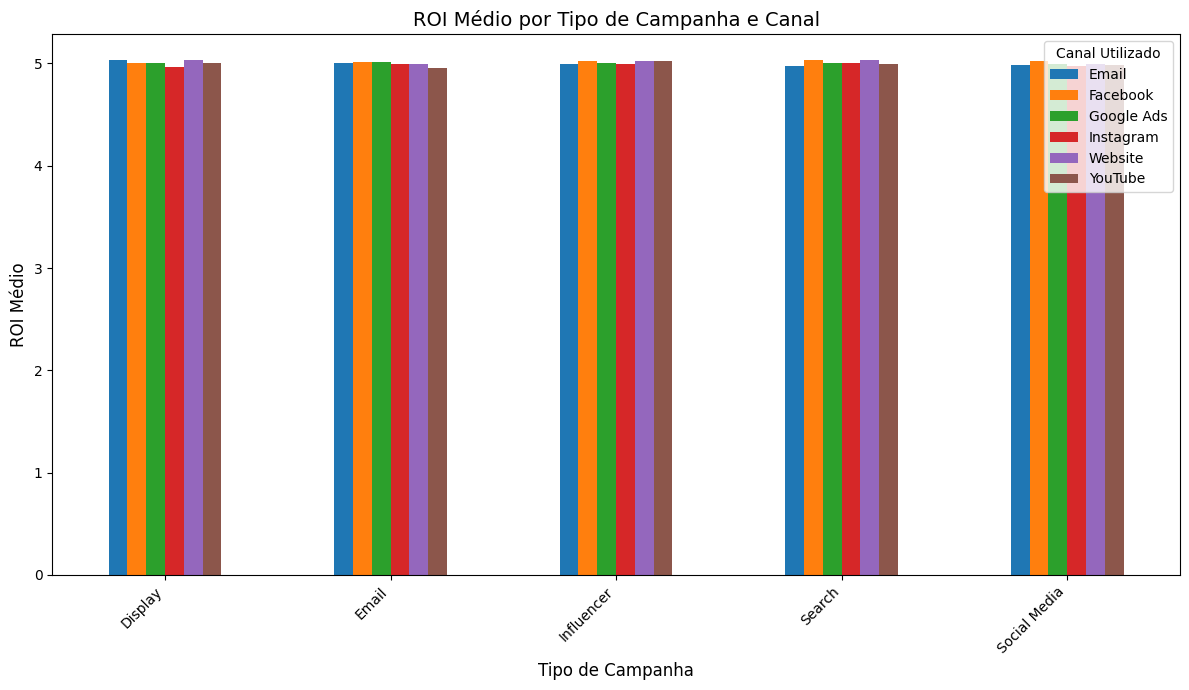

In [ ]:
# Calcular o ROI médio por tipo de campanha e canal
avg_roi = df.groupby(['Campaign_Type', 'Channel_Used'])['ROI'].mean().unstack()

# Plotar gráfico de barras agrupadas
avg_roi.plot(kind='bar', figsize=(12, 7))

# Personalização
plt.title('ROI Médio por Tipo de Campanha e Canal', fontsize=14)
plt.xlabel('Tipo de Campanha', fontsize=12)
plt.ylabel('ROI Médio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Canal Utilizado')
plt.tight_layout()
plt.show()

### Conversão média por audiência.

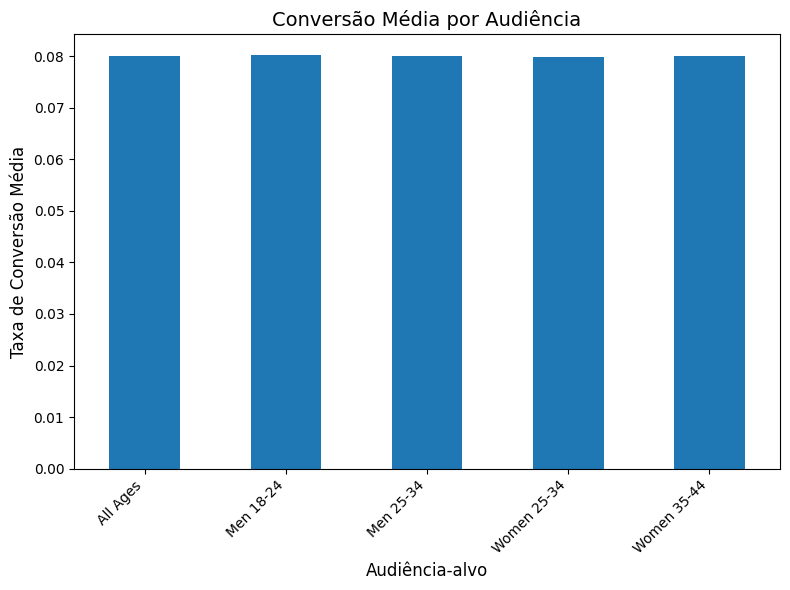

In [ ]:
# Calcular a conversão média por audiência
avg_conversion_by_audience = df.groupby('Target_Audience')['Conversion_Rate'].mean()

# Plotar gráfico de barras
avg_conversion_by_audience.plot(kind='bar', figsize=(8, 6))

# Personalização
plt.title('Conversão Média por Audiência', fontsize=14)
plt.xlabel('Audiência-alvo', fontsize=12)
plt.ylabel('Taxa de Conversão Média', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Comparar ROI por segmento de cliente.

### Verificar se diferentes linguagens impactam a performance.

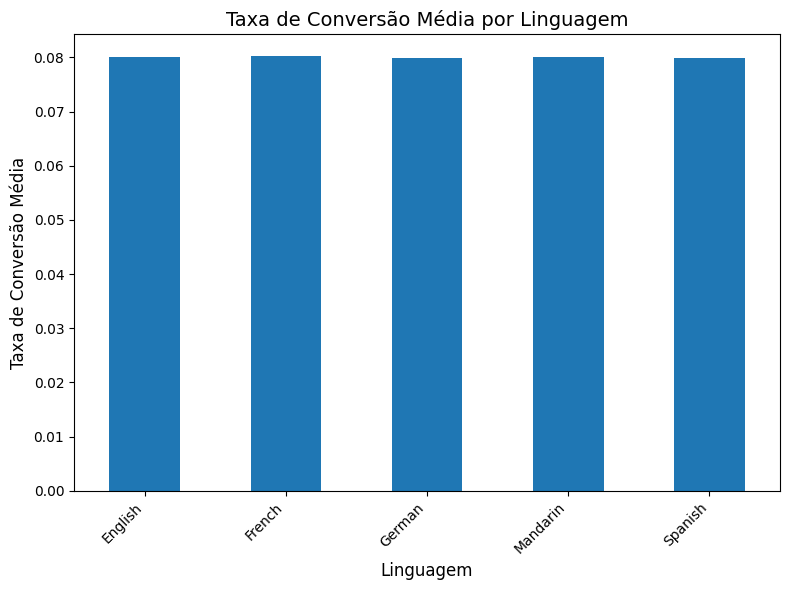

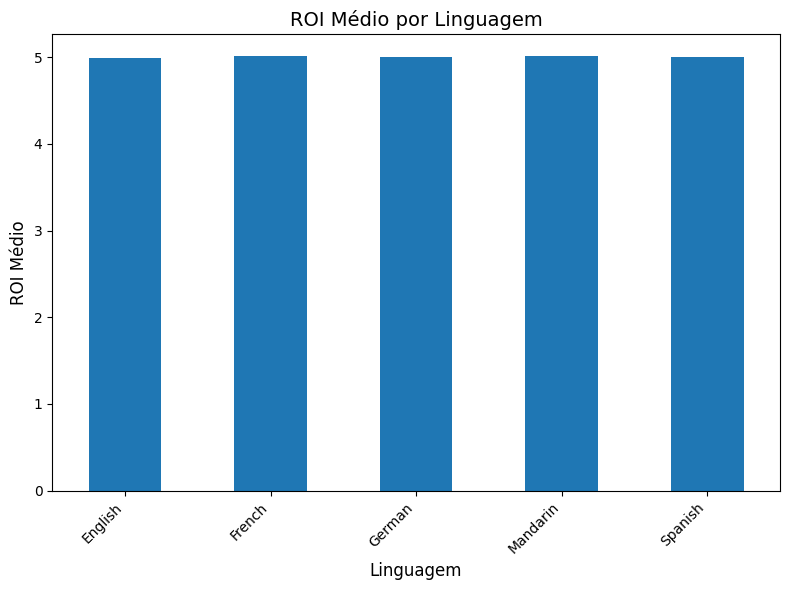

In [ ]:
# Calcular a conversão média por linguagem
avg_conversion_by_language = df.groupby('Language')['Conversion_Rate'].mean()

# Plotar gráfico de barras para conversão média por linguagem
plt.figure(figsize=(8, 6))
avg_conversion_by_language.plot(kind='bar')
plt.title('Taxa de Conversão Média por Linguagem', fontsize=14)
plt.xlabel('Linguagem', fontsize=12)
plt.ylabel('Taxa de Conversão Média', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Calcular o ROI médio por linguagem
avg_roi_by_language = df.groupby('Language')['ROI'].mean()

# Plotar gráfico de barras para ROI médio por linguagem
plt.figure(figsize=(8, 6))
avg_roi_by_language.plot(kind='bar')
plt.title('ROI Médio por Linguagem', fontsize=14)
plt.xlabel('Linguagem', fontsize=12)
plt.ylabel('ROI Médio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Relação entre Impressões → Clicks → Taxa de engajamento.


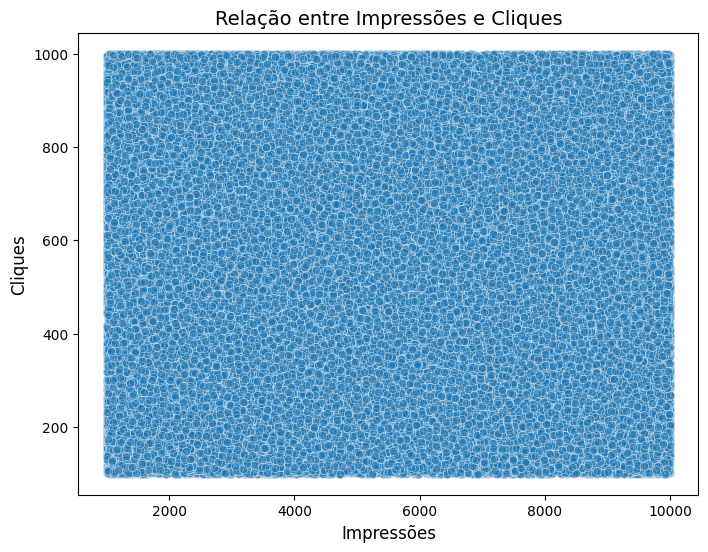

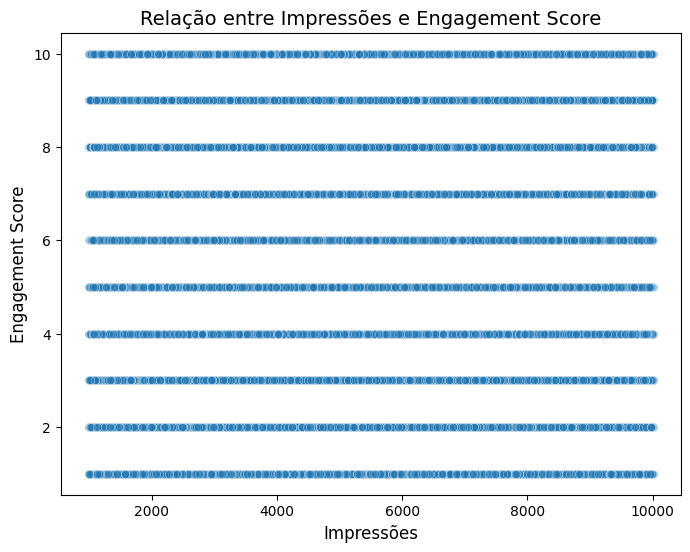

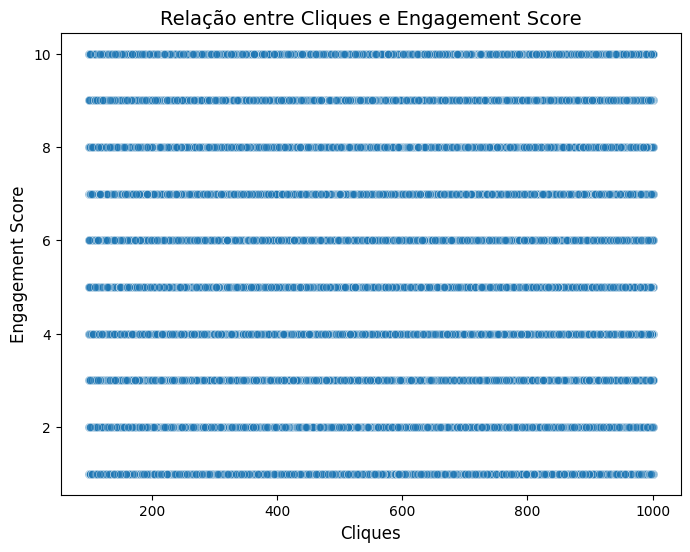

In [ ]:
# Relação entre Impressions e Clicks
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Impressions', y='Clicks', alpha=0.5)
plt.title('Relação entre Impressões e Cliques', fontsize=14)
plt.xlabel('Impressões', fontsize=12)
plt.ylabel('Cliques', fontsize=12)
plt.show()

# Relação entre Impressions e Engagement_Score
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Impressions', y='Engagement_Score', alpha=0.5)
plt.title('Relação entre Impressões e Engagement Score', fontsize=14)
plt.xlabel('Impressões', fontsize=12)
plt.ylabel('Engagement Score', fontsize=12)
plt.show()

# Relação entre Clicks e Engagement_Score
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Clicks', y='Engagement_Score', alpha=0.5)
plt.title('Relação entre Cliques e Engagement Score', fontsize=14)
plt.xlabel('Cliques', fontsize=12)
plt.ylabel('Engagement Score', fontsize=12)
plt.show()

### CTR (Click-through rate) = Clicks / Impressions.

In [ ]:
# Calcular CTR
df['CTR'] = df['Clicks'] / df['Impressions']

# Verificar os primeiros valores e a distribuição
print(df[['Clicks', 'Impressions', 'CTR']].head())
print("\nDistribuição do CTR:")
print(df['CTR'].describe())

   Clicks  Impressions       CTR
0     506         1922  0.263267
1     116         7523  0.015419
2     584         7698  0.075864
3     217         1820  0.119231
4     379         4201  0.090217

Distribuição do CTR:
count    200000.000000
mean          0.140405
std           0.130881
min           0.010054
25%           0.058606
50%           0.099789
75%           0.169699
max           0.992024
Name: CTR, dtype: float64


### Correlação entre EngaTaxa de engajamento e Taxa de conversão.

Correlação entre Engagement_Score e Conversion_Rate: -0.00


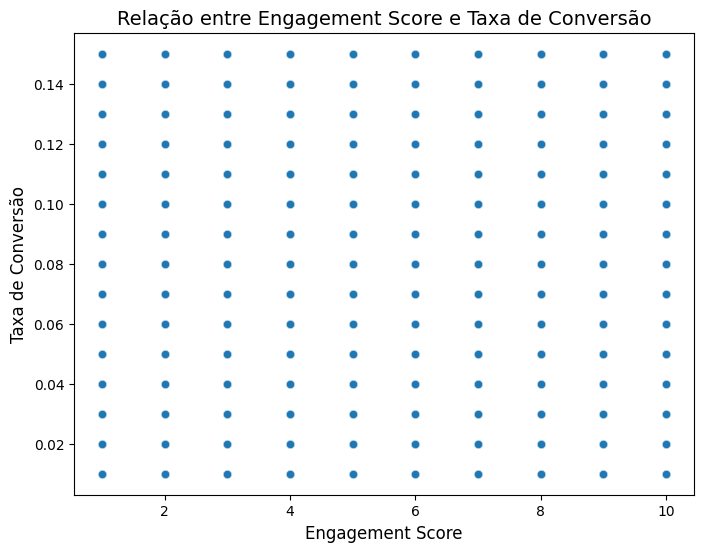

In [ ]:
correlation = df['Engagement_Score'].corr(df['Conversion_Rate'])

print(f"Correlação entre Engagement_Score e Conversion_Rate: {correlation:.2f}")

# Gráfico de dispersão para visualizar a relação
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Engagement_Score', y='Conversion_Rate', alpha=0.5)
plt.title('Relação entre Engagement Score e Taxa de Conversão', fontsize=14)
plt.xlabel('Engagement Score', fontsize=12)
plt.ylabel('Taxa de Conversão', fontsize=12)
plt.show()

### Distribuição de engajamento por canal.

/tmp/ipython-input-1057818492.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Channel_Used', y='Engagement_Score', palette='viridis')


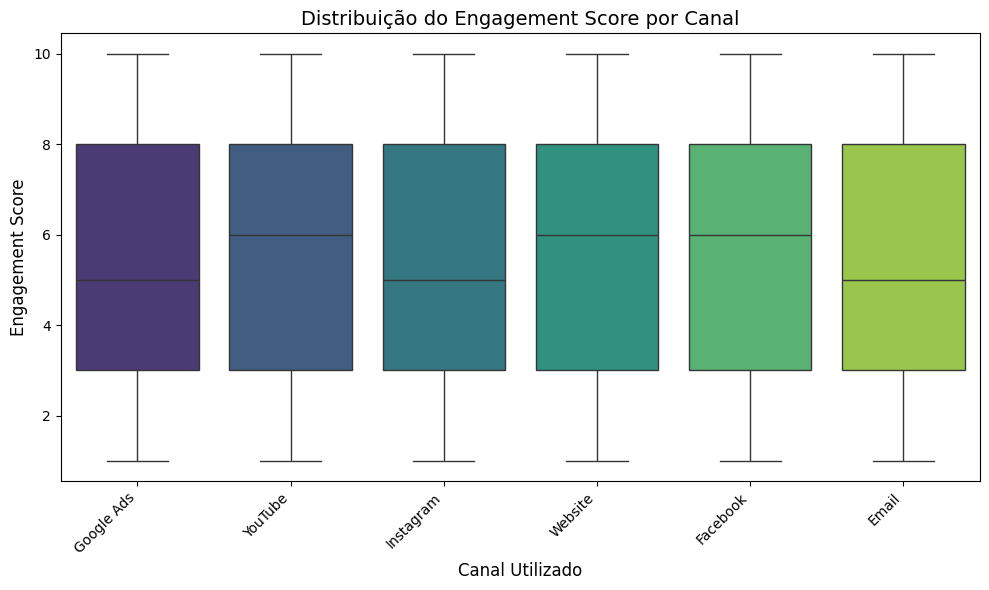

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Channel_Used', y='Engagement_Score', palette='viridis')
plt.title('Distribuição do Engagement Score por Canal', fontsize=14)
plt.xlabel('Canal Utilizado', fontsize=12)
plt.ylabel('Engagement Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Evolução da taxa de conversão ao longo do tempo.

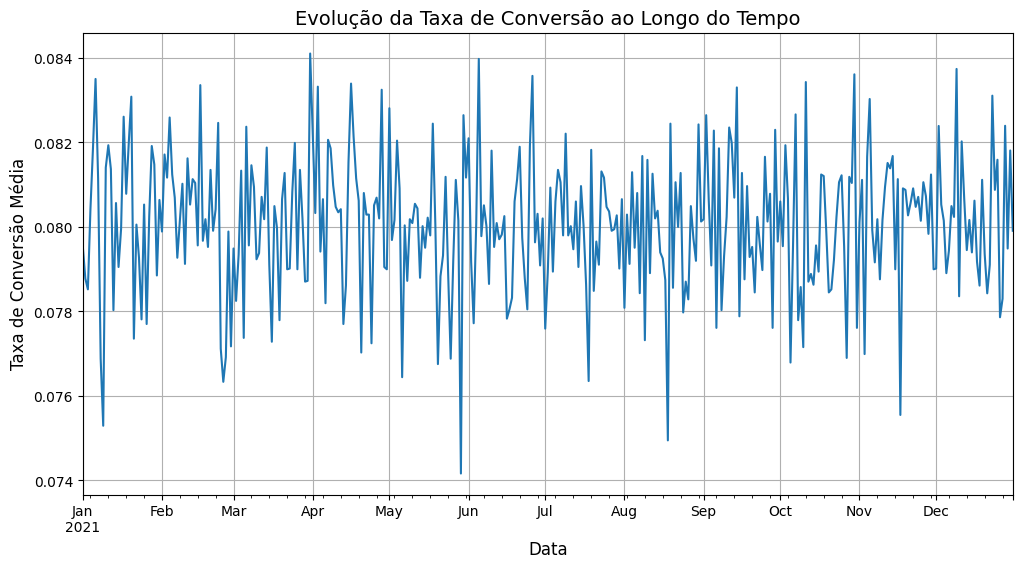

In [ ]:
# Agrupar por data e calcular a taxa de conversão média
daily_conversion_rate = df.groupby('Date')['Conversion_Rate'].mean()

# Plotar a evolução da taxa de conversão ao longo do tempo
plt.figure(figsize=(12, 6))
daily_conversion_rate.plot()
plt.title('Evolução da Taxa de Conversão ao Longo do Tempo', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Taxa de Conversão Média', fontsize=12)
plt.grid(True)
plt.show()

### Identificação de sazonalidade (quais meses/ciclos têm melhor ROI).


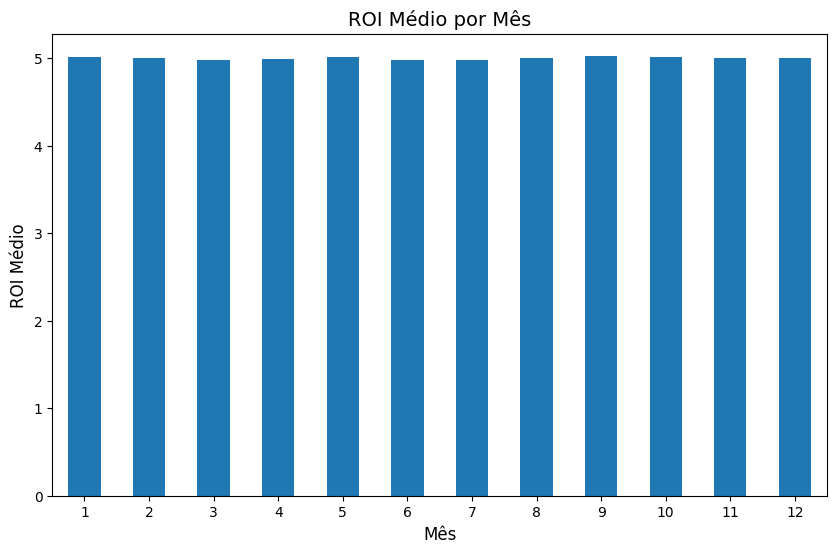

In [ ]:
# Extrair o mês da coluna 'Date'
df['Month'] = df['Date'].dt.month

# Calcular o ROI médio por mês
monthly_roi = df.groupby('Month')['ROI'].mean()

# Plotar o ROI médio por mês
plt.figure(figsize=(10, 6))
monthly_roi.plot(kind='bar')
plt.title('ROI Médio por Mês', fontsize=14)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('ROI Médio', fontsize=12)
plt.xticks(rotation=0)
plt.show()

### Duração da campanha vs. taxa de conversão (curtas performam melhor?)

/tmp/ipython-input-251938525.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Duration', y='Conversion_Rate', palette='viridis')


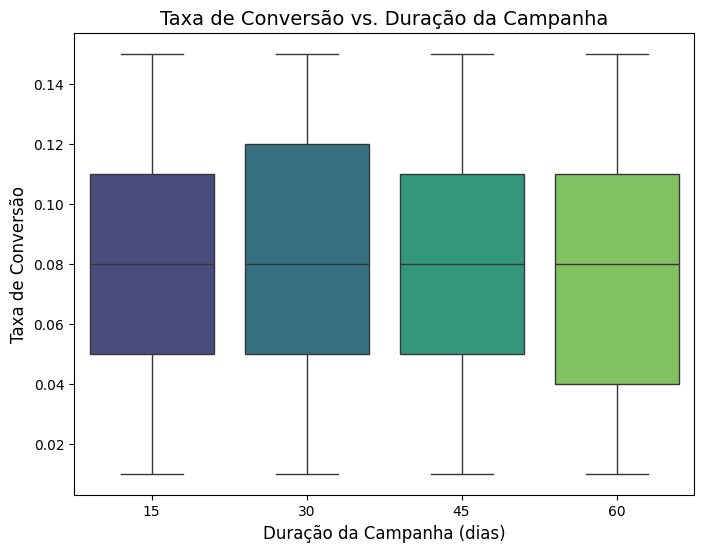

In [ ]:
# Duração da campanha vs. taxa de conversão (boxplot)
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Duration', y='Conversion_Rate', palette='viridis')
plt.title('Taxa de Conversão vs. Duração da Campanha', fontsize=14)
plt.xlabel('Duração da Campanha (dias)', fontsize=12)
plt.ylabel('Taxa de Conversão', fontsize=12)
plt.show()

### Distribuição de campanhas por Location.

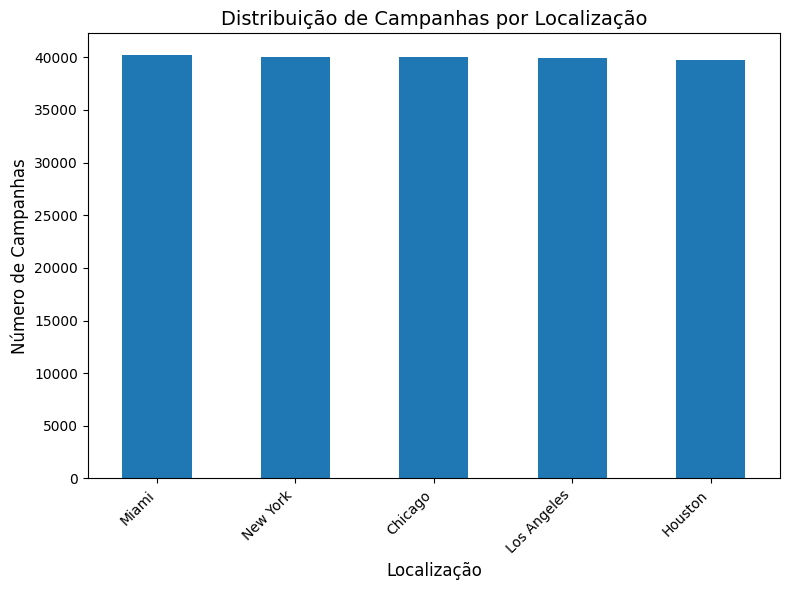

In [ ]:
# Contar o número de campanhas por Location
location_counts = df['Location'].value_counts()

# Plotar gráfico de barras
plt.figure(figsize=(8, 6))
location_counts.plot(kind='bar')
plt.title('Distribuição de Campanhas por Localização', fontsize=14)
plt.xlabel('Localização', fontsize=12)
plt.ylabel('Número de Campanhas', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Conversão média por região.


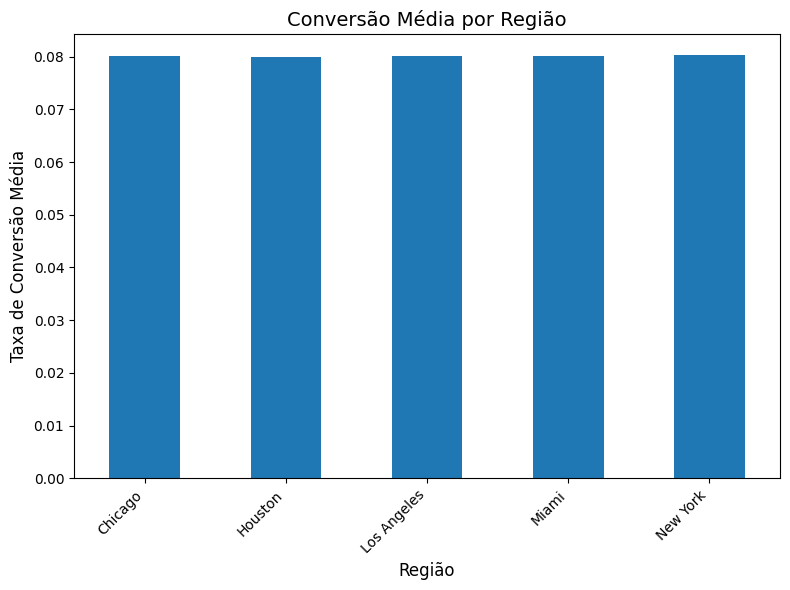

In [ ]:
# Calcular a conversão média por região
avg_conversion_by_location = df.groupby('Location')['Conversion_Rate'].mean()

# Plotar gráfico de barras
plt.figure(figsize=(8, 6))
avg_conversion_by_location.plot(kind='bar')
plt.title('Conversão Média por Região', fontsize=14)
plt.xlabel('Região', fontsize=12)
plt.ylabel('Taxa de Conversão Média', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### ROI por localização → identificar regiões mais rentáveis.

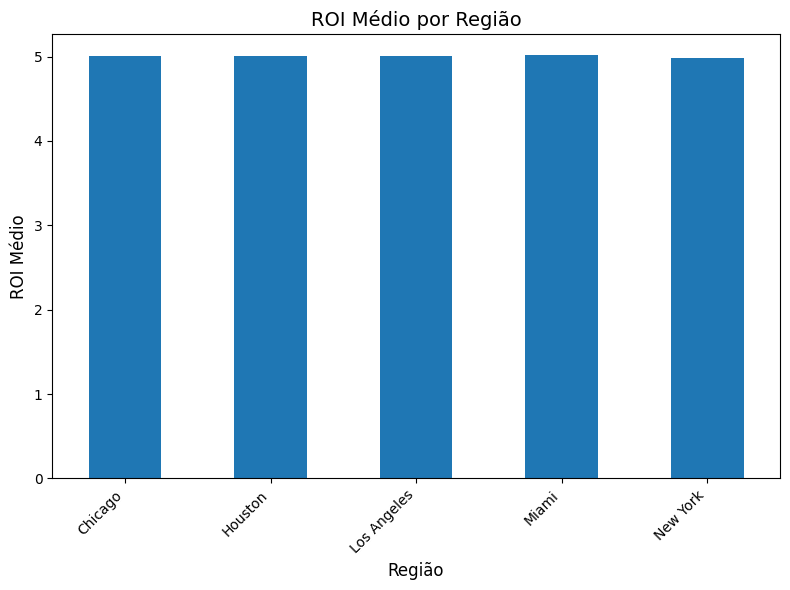

In [ ]:
# Calcular o ROI médio por localização
avg_roi_by_location = df.groupby('Location')['ROI'].mean()

# Plotar gráfico de barras
plt.figure(figsize=(8, 6))
avg_roi_by_location.plot(kind='bar')
plt.title('ROI Médio por Região', fontsize=14)
plt.xlabel('Região', fontsize=12)
plt.ylabel('ROI Médio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### ROI em função de Custo de Aquisição × Taxa de Conversão.

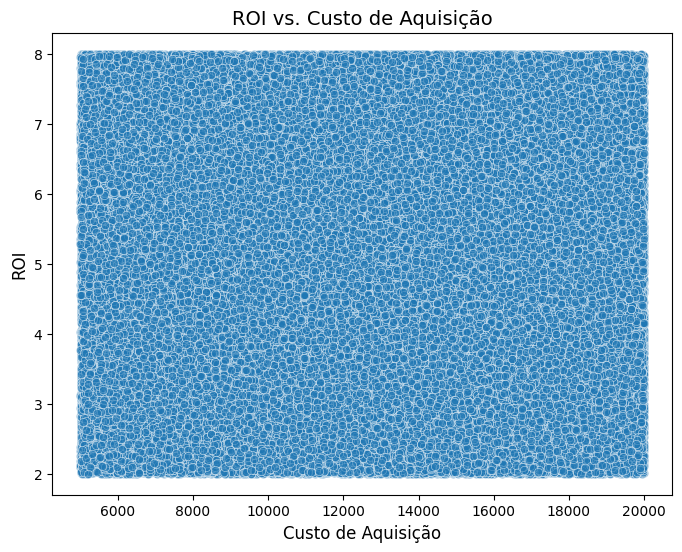

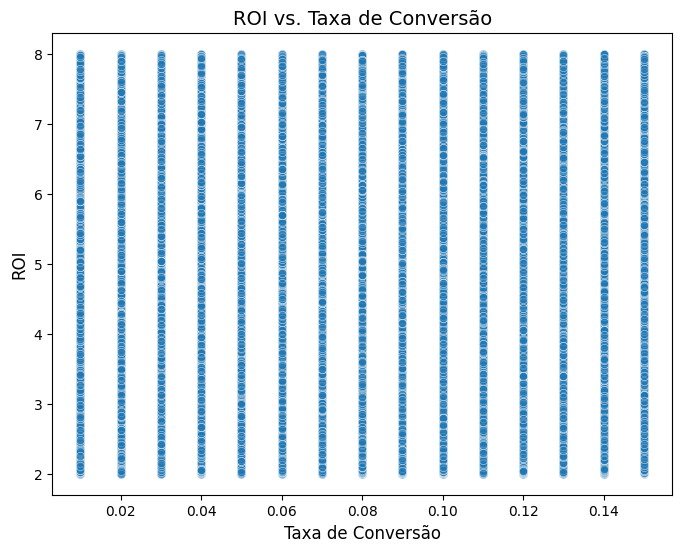


Matriz de Correlação:


,Acquisition_Cost,Conversion_Rate,ROI
Acquisition_Cost,1.000000,0.000718,0.004585
Conversion_Rate,0.000718,1.000000,-0.001143
ROI,0.004585,-0.001143,1.000000


In [ ]:
# Gráfico de dispersão: ROI vs. Custo de Aquisição
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Acquisition_Cost', y='ROI', alpha=0.6)
plt.title('ROI vs. Custo de Aquisição', fontsize=14)
plt.xlabel('Custo de Aquisição', fontsize=12)
plt.ylabel('ROI', fontsize=12)
plt.show()

# Gráfico de dispersão: ROI vs. Taxa de Conversão
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Conversion_Rate', y='ROI', alpha=0.6)
plt.title('ROI vs. Taxa de Conversão', fontsize=14)
plt.xlabel('Taxa de Conversão', fontsize=12)
plt.ylabel('ROI', fontsize=12)
plt.show()

# Calcular a correlação entre as variáveis
correlation_matrix = df[['Acquisition_Cost', 'Conversion_Rate', 'ROI']].corr()
print("\nMatriz de Correlação:")
display(correlation_matrix)

### Campanhas com alta conversão mas ROI baixo (custo elevado).

In [ ]:
# Definir limites para alta conversão e baixo ROI (usando percentis como exemplo)
high_conversion_threshold = df['Conversion_Rate'].quantile(0.75)  # Ex: 75º percentil
low_roi_threshold = df['ROI'].quantile(0.25)                      # Ex: 25º percentil

# Filtrar campanhas com alta conversão e baixo ROI
high_conversion_low_roi_campaigns = df[
    (df['Conversion_Rate'] > high_conversion_threshold) &
    (df['ROI'] < low_roi_threshold)
]

# Exibir informações sobre essas campanhas
print(f"Campanhas com Taxa de Conversão acima de {high_conversion_threshold:.2f} e ROI abaixo de {low_roi_threshold:.2f}:")
display(high_conversion_low_roi_campaigns[[
    'Campaign_ID', 'Company', 'Campaign_Type', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Channel_Used', 'Location'
]].head()) # Exibe as primeiras 5 para brevidade

Campanhas com Taxa de Conversão acima de 0.12 e ROI abaixo de 3.50:


,Campaign_ID,Company,Campaign_Type,Conversion_Rate,Acquisition_Cost,ROI,Channel_Used,Location
6,7,NexGen Systems,Email,0.13,11067.0,2.86,Website,Los Angeles
22,23,NexGen Systems,Social Media,0.13,8699.0,2.12,YouTube,Miami
33,34,Alpha Innovations,Influencer,0.14,15082.0,2.71,Google Ads,Los Angeles
84,85,Alpha Innovations,Influencer,0.15,15866.0,2.30,Email,Houston
86,87,DataTech Solutions,Email,0.15,19026.0,2.22,YouTube,Miami


### Segmentos com baixo custo de aquisição mas alta taxa de conversão.

In [ ]:
# Calcular a média de custo de aquisição e taxa de conversão por segmento de cliente
segment_performance = df.groupby('Customer_Segment').agg({
    'Acquisition_Cost': 'mean',
    'Conversion_Rate': 'mean'
}).reset_index()

# Exibir a performance por segmento
print("Performance por Segmento de Cliente:")
display(segment_performance)

# Opcional: Identificar segmentos que se encaixam nos critérios (exemplo usando percentis)
low_cost_threshold = segment_performance['Acquisition_Cost'].quantile(0.25) # Ex: 25º percentil
high_conversion_threshold = segment_performance['Conversion_Rate'].quantile(0.75) # Ex: 75º percentil

high_performing_segments = segment_performance[
    (segment_performance['Acquisition_Cost'] < low_cost_threshold) &
    (segment_performance['Conversion_Rate'] > high_conversion_threshold)
]

if not high_performing_segments.empty:
    print(f"\nSegmentos com Custo de Aquisição abaixo de {low_cost_threshold:.2f} e Taxa de Conversão acima de {high_conversion_threshold:.2f}:")
    display(high_performing_segments)
else:
    print("\nNão foram encontrados segmentos que se encaixam nesses critérios (usando os percentis definidos).")

Performance por Segmento de Cliente:


,Customer_Segment,Acquisition_Cost,Conversion_Rate
0,Fashionistas,12503.445574,0.079794
1,Foodies,12524.558148,0.080257
2,Health & Wellness,12504.418346,0.079945
3,Outdoor Adventurers,12509.128540,0.080180
4,Tech Enthusiasts,12480.392991,0.080168



Não foram encontrados segmentos que se encaixam nesses critérios (usando os percentis definidos).


### Cálculo de CAC médio = soma(Custo de Aquisição) / número de conversões).

In [ ]:
# Assumindo que o número de conversões por campanha pode ser estimado por Clicks * Conversion_Rate
df['Estimated_Conversions'] = df['Clicks'] * df['Conversion_Rate']

# Calcular o custo total de aquisição e o total de conversões estimadas
total_acquisition_cost = df['Acquisition_Cost'].sum()
total_estimated_conversions = df['Estimated_Conversions'].sum()

# Calcular o CAC médio agregado
# Evitar divisão por zero caso não haja conversões estimadas
if total_estimated_conversions > 0:
    cac_medio = total_acquisition_cost / total_estimated_conversions
    print(f"Custo Total de Aquisição: {total_acquisition_cost:,.2f}")
    print(f"Total de Conversões Estimadas: {total_estimated_conversions:,.2f}")
    print(f"\nCAC Médio (baseado em Clicks * Conversion_Rate): {cac_medio:,.2f}")
else:
    print("Não foi possível calcular o CAC médio, pois o total de conversões estimadas é zero.")

Custo Total de Aquisição: 2,500,878,608.00
Total de Conversões Estimadas: 8,804,579.69

CAC Médio (baseado em Clicks * Conversion_Rate): 284.04


### ROI agregado por empresa.

ROI Médio por Empresa:


,ROI
Company,
Alpha Innovations,5.005944
DataTech Solutions,5.005537
Innovate Industries,5.002175
NexGen Systems,4.991353
TechCorp,5.007143


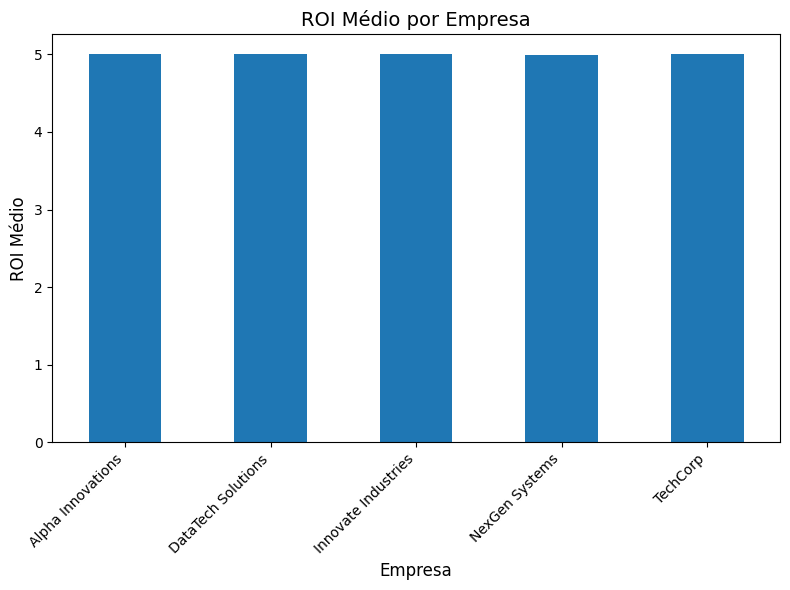

In [ ]:
avg_roi_by_company = df.groupby('Company')['ROI'].mean()

print("ROI Médio por Empresa:")
display(avg_roi_by_company)

# Opcional: Plotar um gráfico para visualizar
plt.figure(figsize=(8, 6))
avg_roi_by_company.plot(kind='bar')
plt.title('ROI Médio por Empresa', fontsize=14)
plt.xlabel('Empresa', fontsize=12)
plt.ylabel('ROI Médio', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Identificação de top 10 campanhas mais rentáveis.

In [ ]:
top_10_profitable_campaigns = df.sort_values(by='ROI', ascending=False).head(10)

print("Top 10 Campanhas Mais Rentáveis (por ROI):")
display(top_10_profitable_campaigns[[
    'Campaign_ID', 'Company', 'Campaign_Type', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Channel_Used', 'Location', 'Date'
]])

Top 10 Campanhas Mais Rentáveis (por ROI):


,Campaign_ID,Company,Campaign_Type,Conversion_Rate,Acquisition_Cost,ROI,Channel_Used,Location,Date
65640,65641,Alpha Innovations,Search,0.09,18624.0,8.0,Website,Miami,2021-11-02
143790,143791,Alpha Innovations,Influencer,0.06,17371.0,8.0,Website,Los Angeles,2021-12-12
143503,143504,Innovate Industries,Influencer,0.04,5889.0,8.0,YouTube,New York,2021-02-28
121639,121640,TechCorp,Influencer,0.14,7081.0,8.0,Google Ads,Chicago,2021-04-05
120917,120918,TechCorp,Social Media,0.11,6677.0,8.0,Website,Miami,2021-04-13
73364,73365,Innovate Industries,Display,0.15,5277.0,8.0,Website,New York,2021-12-31
48870,48871,TechCorp,Display,0.12,6670.0,8.0,Website,Miami,2021-11-22
42868,42869,DataTech Solutions,Display,0.01,5659.0,8.0,Website,Chicago,2021-06-13
42999,43000,NexGen Systems,Email,0.09,12833.0,8.0,Google Ads,Chicago,2021-10-22
83445,83446,Alpha Innovations,Search,0.04,18956.0,8.0,Email,Houston,2021-08-14


### Identificação de campanhas deficitárias (ROI < 0).

In [ ]:
unprofitable_campaigns = df[df['ROI'] < 0]

print("Campanhas Deficitárias (ROI < 0):")
if not unprofitable_campaigns.empty:
    display(unprofitable_campaigns[[
        'Campaign_ID', 'Company', 'Campaign_Type', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Channel_Used', 'Location', 'Date'
    ]])
else:
    print("Não foram encontradas campanhas com ROI negativo.")

Campanhas Deficitárias (ROI < 0):
Não foram encontradas campanhas com ROI negativo.


### Matriz de correlação

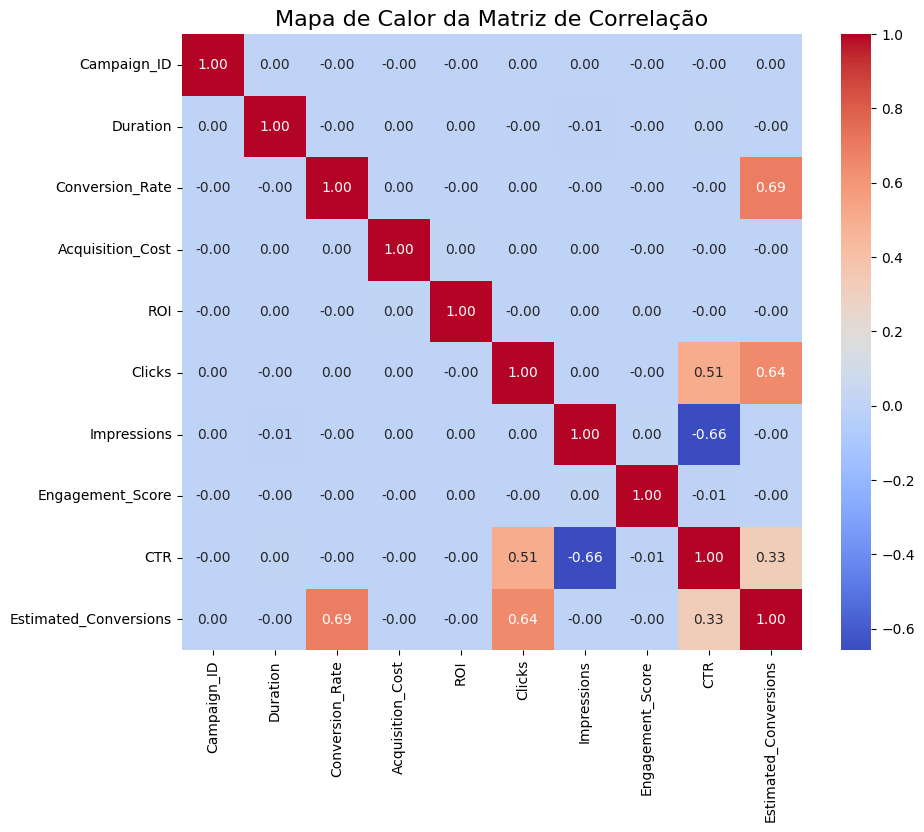

In [ ]:
# Selecionar apenas as colunas numéricas
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

# Calcular a matriz de correlação
correlation_matrix = df[numerical_cols].corr()

# Plotar o heatmap da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor da Matriz de Correlação', fontsize=16)
plt.show()

# 📊 Insights de Negócio da Análise Exploratória (EDA)



## Principais Insights da Análise Exploratória (EDA)

A análise exploratória dos dados revelou diversos padrões e relações que podem impactar diretamente as decisões e estratégias de marketing. Abaixo, apresentamos um resumo dos principais insights obtidos a partir de cada gráfico e análise:

### 1. Quantidade de Campanhas por Empresa e por Tipo de Campanha

*   **Padrão:** O gráfico de barras empilhadas mostra que a distribuição de tipos de campanha é relativamente uniforme entre as empresas. Todas as empresas parecem utilizar uma mistura semelhante de campanhas de Display, Email, Influencer, Search e Social Media.
*   **Impacto no Negócio:** Isso sugere que não há uma especialização clara por empresa em relação aos tipos de campanha. As empresas podem estar seguindo estratégias de marketing diversificadas, o que pode ser positivo para alcançar diferentes públicos, mas também pode indicar falta de foco ou otimização em canais específicos. Uma análise mais aprofundada do ROI por tipo de campanha e empresa pode revelar se alguma empresa se destaca em um tipo específico.

### 2. Duração Média das Campanhas por Tipo de Campanha

*   **Padrão:** O gráfico de barras indica que a duração média das campanhas é bastante similar entre todos os tipos de campanha, girando em torno de 37 dias.
*   **Impacto no Negócio:** A uniformidade na duração média pode sugerir uma abordagem padronizada no planejamento das campanhas. Se a duração ideal varia significativamente por tipo de campanha ou objetivo, pode haver oportunidades de otimização ajustando a duração para maximizar a performance.

### 3. Comparação entre Canais Usados em Termos de Volume de Campanhas

*   **Padrão:** O gráfico de barras mostra que a distribuição do volume de campanhas entre os canais utilizados é relativamente equilibrada, com pequenas variações. Email, Google Ads, YouTube, Instagram, Website e Facebook são utilizados em volumes comparáveis.
*   **Impacto no Negócio:** Essa distribuição equilibrada de canais sugere que as empresas estão buscando uma presença multicanal. Entender a performance (principalmente ROI e taxa de conversão) de cada canal é crucial para alocar o orçamento de forma mais eficaz e focar nos canais que geram melhor retorno.

### 4. Distribuição da Taxa de Conversão por Tipo de Campanha

*   **Padrão:** O boxplot mostra que a distribuição da taxa de conversão é bastante semelhante entre os diferentes tipos de campanha. As medianas e as caixas (intervalo interquartil) são muito próximas.
*   **Impacto no Negócio:** A similaridade nas taxas de conversão médias entre os tipos de campanha pode indicar que, em média, nenhum tipo de campanha se destaca significativamente em gerar conversões. Isso pode levar a uma análise mais granular para identificar fatores (como audiência, canal, duração) que influenciam a conversão dentro de cada tipo de campanha.

### 5. Campanhas com Melhor e Pior ROI

*   **Padrão:** As tabelas identificam as campanhas com os maiores e menores ROIs. As campanhas de maior ROI apresentam uma variedade de tipos de campanha, canais e durações. As campanhas de menor ROI também são diversas.
*   **Impacto no Negócio:** A identificação das campanhas de melhor e pior performance é fundamental para aprender com o sucesso e o fracasso. Analisar as características comuns das campanhas de alto ROI (ex: combinação de canal e tipo de campanha, audiência, duração) pode fornecer insights valiosos para replicar estratégias bem-sucedidas. Da mesma forma, entender o que deu errado nas campanhas de baixo ROI pode ajudar a evitar erros futuros.

### 6. Relação entre Custo de Aquisição por Tipo de Campanha

*   **Padrão:** O boxplot mostra que a distribuição do custo de aquisição é bastante similar entre os diferentes tipos de campanha.
*   **Impacto no Negócio:** Semelhante à taxa de conversão, a uniformidade no custo de aquisição por tipo de campanha sugere que, em média, o custo para adquirir um cliente é parecido independentemente do tipo de campanha. Isso reforça a necessidade de analisar outros fatores (como ROI) para determinar a eficácia de cada tipo de campanha.

### 7. Média de Custo de Aquisição por Tipo de Campanha

*   **Padrão:** O gráfico de barras confirma que a média de custo de aquisição é muito similar entre todos os tipos de campanha.
*   **Impacto no Negócio:** Este insight complementa o anterior, reforçando que o custo médio por aquisição não é um fator diferenciador entre os tipos de campanha na média agregada. A análise de ROI se torna ainda mais crucial para entender a rentabilidade real.

### 8. Comparação do ROI Médio por Tipo de Campanha e Canal

*   **Padrão:** O gráfico de barras agrupadas mostra que o ROI médio é muito semelhante em todas as combinações de tipo de campanha e canal.
*   **Impacto no Negócio:** Esta é uma observação importante. A aparente falta de variação significativa no ROI médio entre diferentes tipos de campanha e canais pode indicar que a performance é influenciada por outros fatores não explicitamente capturados nesta agregação, ou que as estratégias atuais não estão otimizando a combinação canal/tipo de campanha para ROI. Uma análise mais profunda dos dados brutos e a inclusão de outras variáveis podem ser necessárias para identificar padrões de ROI mais claros.

### 9. Conversão Média por Audiência

*   **Padrão:** O gráfico de barras mostra que a taxa de conversão média é muito similar entre os diferentes públicos-alvo.
*   **Impacto no Negócio:** A uniformidade na taxa de conversão por audiência sugere que, na média, as campanhas estão convertendo de forma semelhante em todos os segmentos de público. Isso pode indicar que as estratégias de segmentação não estão gerando um diferencial significativo na taxa de conversão.

### 10. Impacto de Diferentes Linguagens na Performance

*   **Padrão:** Os gráficos de barras mostram que tanto a taxa de conversão média quanto o ROI médio são muito semelhantes entre as diferentes linguagens utilizadas nas campanhas.
*   **Impacto no Negócio:** A linguagem parece não ser um fator determinante na performance das campanhas, em termos de conversão e ROI médios. Isso pode indicar que a mensagem ou a oferta são mais relevantes do que a linguagem para o público-alvo, ou que a distribuição das campanhas por linguagem e outros fatores relevantes é equilibrada.

### 11. Relação entre Impressões, Cliques e Engagement Score

*   **Padrão:** Os gráficos de dispersão mostram que não há uma correlação linear clara entre Impressões, Cliques e Engagement Score. Os pontos estão dispersos sem um padrão definido.
*   **Impacto no Negócio:** A falta de correlação direta sugere que um alto número de impressões ou cliques não garante automaticamente um alto Engagement Score. O engajamento parece ser influenciado por outros fatores além do volume de visualizações ou cliques. Isso destaca a importância de otimizar o conteúdo e a relevância da campanha para impulsionar o engajamento, e não apenas focar em métricas de volume.

### 12. CTR (Click-through Rate)

*   **Padrão:** A análise da coluna `CTR` mostra uma distribuição com média de aproximadamente 14%.
*   **Impacto no Negócio:** O CTR é uma métrica importante de engajamento inicial. A distribuição do CTR fornece uma linha de base para avaliar a eficácia dos anúncios e criativos em gerar cliques. Campanhas com CTRs significativamente abaixo da média podem precisar de otimização no copy, design ou segmentação.

### 13. Correlação entre Engagement Score e Taxa de Conversão

*   **Padrão:** A correlação calculada é próxima de zero, e o gráfico de dispersão mostra uma nuvem de pontos sem um padrão aparente.
*   **Impacto no Negócio:** A falta de correlação linear entre Engagement Score e Taxa de Conversão é um insight contraintuitivo. Geralmente, espera-se que um maior engajamento leve a uma maior conversão. Isso pode indicar que o Engagement Score, conforme definido neste dataset, não está capturando os aspectos do engajamento que realmente impulsionam a conversão, ou que há outros fatores mediadores importantes. Uma análise mais aprofundada de como o Engagement Score é calculado ou a inclusão de outras métricas de engajamento pode ser necessária.

### 14. Distribuição de Engajamento por Canal

*   **Padrão:** O boxplot mostra que a distribuição do Engagement Score é bastante similar entre os diferentes canais utilizados.
*   **Impacto no Negócio:** Semelhante a outras métricas, a uniformidade na distribuição do Engagement Score por canal sugere que, em média, o nível de engajamento gerado é parecido independentemente do canal. Isso pode indicar que a qualidade do conteúdo e a relevância para a audiência são mais importantes do que o canal em si para impulsionar o engajamento.

### 15. Evolução da Taxa de Conversão ao Longo do Tempo

*   **Padrão:** O gráfico de linha mostra flutuações na taxa de conversão média diária ao longo do ano, mas sem uma tendência clara de crescimento ou queda significativa.
*   **Impacto no Negócio:** A ausência de uma tendência forte na taxa de conversão ao longo do tempo pode indicar que as estratégias de marketing estão mantendo um nível de performance relativamente estável. A análise das flutuações pode ajudar a identificar picos ou quedas pontuais que podem estar associados a eventos específicos, lançamentos de campanha ou fatores externos.

### 16. Identificação de Sazonalidade (ROI por Mês)

*   **Padrão:** O gráfico de barras mostra que o ROI médio é muito semelhante em todos os meses do ano. Não há uma sazonalidade clara identificada com base apenas no mês.
*   **Impacto no Negócio:** A falta de sazonalidade no ROI médio mensal sugere que a performance das campanhas não é fortemente influenciada pelo mês do ano. Isso pode indicar que os produtos/serviços promovidos não têm uma demanda sazonal pronunciada, ou que as estratégias de marketing estão bem distribuídas ao longo do ano. Análises mais detalhadas, considerando combinações de mês com tipo de campanha ou audiência, podem revelar padrões sazonais mais específicos.

### 17. Duração da Campanha vs. Taxa de Conversão

*   **Padrão:** O boxplot mostra que a distribuição da taxa de conversão é semelhante para diferentes durações de campanha (15, 30, 45, 60 dias).
*   **Impacto no Negócio:** A duração da campanha, por si só, não parece ter um impacto significativo na taxa de conversão média. Isso sugere que focar apenas na duração da campanha pode não ser uma estratégia eficaz para otimizar a conversão. Outros fatores, como o conteúdo da campanha, a audiência e o canal, podem ser mais determinantes.

### 18. Distribuição de Campanhas por Localização

*   **Padrão:** O gráfico de barras mostra que a distribuição do volume de campanhas é muito similar entre as diferentes localizações.
*   **Impacto no Negócio:** As empresas estão distribuindo suas campanhas de forma relativamente uniforme entre as localizações. Entender a performance (conversão e ROI) por localização é crucial para otimizar a alocação de recursos e focar nas regiões mais rentáveis.

### 19. Conversão Média por Região

*   **Padrão:** O gráfico de barras mostra que a taxa de conversão média é muito similar entre as diferentes regiões.
*   **Impacto no Negócio:** Assim como outros fatores analisados, a localização não parece ser um fator que influencia significativamente a taxa de conversão média.

### 20. ROI por Localização

*   **Padrão:** O gráfico de barras mostra que o ROI médio é muito similar entre as diferentes regiões.
*   **Impacto no Negócio:** A uniformidade no ROI médio por localização sugere que, em média, as campanhas estão gerando um retorno semelhante em todas as regiões. Isso pode indicar que as estratégias de marketing atuais não estão explorando as particularidades de cada região para otimizar o ROI.

### 21. Relação entre ROI, Custo de Aquisição e Taxa de Conversão

*   **Padrão:** Os gráficos de dispersão e a matriz de correlação mostram correlações muito baixas entre ROI, Custo de Aquisição e Taxa de Conversão.
*   **Impacto no Negócio:** A falta de correlação linear direta entre essas métricas é um insight surpreendente. O ROI é calculado a partir do custo e da receita (que está relacionada à conversão), então espera-se alguma relação. Isso pode indicar que a fórmula ou os dados utilizados para calcular o ROI neste dataset apresentam alguma particularidade, ou que há outros fatores não considerados que influenciam fortemente o ROI, diluindo a relação direta com custo e conversão.

### 22. Campanhas com Alta Conversão mas ROI Baixo

*   **Padrão:** A tabela identifica campanhas que, apesar de terem uma taxa de conversão acima de um determinado limiar, apresentam um ROI abaixo de outro limiar. As campanhas identificadas têm custos de aquisição variados.
*   **Impacto no Negócio:** Identificar essas campanhas é crucial para otimizar a rentabilidade. Uma alta taxa de conversão é positiva, mas se o custo para gerar essa conversão for proibitivo, o ROI será baixo. Nesses casos, é importante investigar o que está elevando o custo de aquisição (ex: ineficiência do canal, segmentação ampla demais) e buscar formas de reduzir o custo mantendo ou aumentando a taxa de conversão.

### 23. Segmentos com Baixo Custo de Aquisição mas Alta Taxa de Conversão

*   **Padrão:** A análise calculou a performance média por segmento de cliente. No entanto, com os limiares definidos (percentis), não foram encontrados segmentos que se encaixam simultaneamente nos critérios de baixo custo de aquisição e alta taxa de conversão.
*   **Impacto no Negócio:** A ausência de segmentos que claramente se destacam em termos de baixo custo e alta conversão, com base nos percentis utilizados, sugere que não há "segmentos de ouro" óbvios na média agregada. Isso pode indicar que a otimização da performance precisa ser mais granular, considerando combinações de segmento com outros fatores como tipo de campanha e canal.

### 24. CAC Médio

*   **Padrão:** O cálculo forneceu um CAC médio agregado de aproximadamente 284.04 (baseado em Clicks * Conversion_Rate como estimativa de conversões).
*   **Impacto no Negócio:** O CAC médio é uma métrica financeira fundamental. Conhecer o CAC médio ajuda a entender o custo geral de aquisição de clientes. É importante comparar este CAC com o Lifetime Value (LTV) dos clientes para avaliar a sustentabilidade do negócio. A análise do CAC por diferentes dimensões (ex: por canal, por segmento) pode revelar onde é mais eficiente adquirir clientes.

### 25. ROI Agregado por Empresa

*   **Padrão:** A análise mostra que o ROI médio agregado é muito similar entre todas as empresas.
*   **Impacto no Negócio:** A uniformidade no ROI médio por empresa sugere que, em média, todas as empresas estão obtendo um retorno semelhante de seus investimentos em marketing. Isso pode indicar que as estratégias de marketing a nível de empresa são comparáveis, ou que os fatores que influenciam o ROI são consistentes em todas as empresas.

### 26. Top 10 Campanhas Mais Rentáveis

*   **Padrão:** A tabela lista as 10 campanhas com maior ROI. Essas campanhas apresentam uma variedade de características (empresa, tipo, canal, localização, etc.).
*   **Impacto no Negócio:** Estudar as características e estratégias por trás dessas campanhas de alto ROI é crucial para identificar as melhores práticas e replicá-las em futuras campanhas. Analisar o que tornou essas campanhas tão bem-sucedidas pode fornecer insights acionáveis para otimizar a performance geral do marketing.

### 27. Campanhas Deficitárias (ROI < 0)

*   **Padrão:** A análise indicou que não foram encontradas campanhas com ROI negativo neste dataset.
*   **Impacto no Negócio:** A ausência de campanhas deficitárias é um ponto positivo, sugerindo que, em geral, as campanhas estão gerando algum nível de retorno. No entanto, é importante notar que um ROI positivo não significa necessariamente um bom ROI. A identificação de campanhas com ROI baixo (mesmo que positivo) e a análise de seus fatores podem ser igualmente importantes para otimizar a rentabilidade.

### 28. Matriz de Correlação

*   **Padrão:** O heatmap mostra as correlações entre as variáveis numéricas. As correlações entre a maioria das variáveis são muito baixas, próximas de zero. As correlações mais notáveis são entre Clicks e Estimated_Conversions (0.64) e entre Conversion_Rate e Estimated_Conversions (0.69), o que é esperado, já que Estimated_Conversions foi calculada a partir delas. Há também uma correlação negativa moderada entre Impressions e CTR (-0.66).
*   **Impacto no Negócio:** A baixa correlação entre a maioria das variáveis numéricas sugere que não há relações lineares fortes e simples entre elas. Isso implica que a performance das campanhas (ROI, Taxa de Conversão) não é determinada por um único fator isolado, mas sim por uma combinação complexa de variáveis e interações. A correlação negativa entre Impressions e CTR é interessante: à medida que as impressões aumentam, o CTR tende a diminuir. Isso pode ocorrer se as campanhas com maior alcance (mais impressões) forem menos direcionadas ou relevantes para o público, resultando em uma menor taxa de cliques. O impacto no negócio é que focar apenas em aumentar as impressões pode não ser eficaz para impulsionar o engajamento (CTR) e, potencialmente, a conversão. É importante otimizar a relevância e a segmentação, mesmo em campanhas de grande alcance.

---

**Em resumo:** A análise exploratória inicial sugere que os dados são relativamente equilibrados e sem valores nulos. No entanto, muitas das métricas de performance (Taxa de Conversão, ROI, Custo de Aquisição, Engagement Score) e as características das campanhas (Tipo, Canal, Audiência, Localização, Linguagem, Duração) mostram distribuições e médias muito semelhantes quando analisadas de forma agregada. As correlações entre as variáveis numéricas são, em sua maioria, baixas.

Isso indica que a performance das campanhas neste dataset não é impulsionada por um ou dois fatores óbvios. Para obter insights mais profundos e identificar oportunidades de otimização, seria necessário realizar análises mais granulares, como:

*   Análise de interações entre variáveis (ex: ROI por combinação específica de Canal e Target Audience).
*   Análise de clusters de campanhas com performance similar para identificar padrões comuns.
*   Análise da distribuição completa das métricas, não apenas médias e medianas.
*   Considerar a criação de features adicionais conforme sugerido no plano inicial (CTR, Custo_por_Click, etc.) para explorar novas relações.

A ausência de campanhas com ROI negativo é um bom sinal, mas otimizar as campanhas de baixo ROI positivo e replicar as estratégias das campanhas de alto ROI continuam sendo focos importantes para melhorar a rentabilidade geral.